<a href="https://colab.research.google.com/github/subashini123-ctrl/Deep-Learning-for-Vision/blob/main/Experiment2_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GLCM Features - Contrast: 627.19, Energy: 0.78


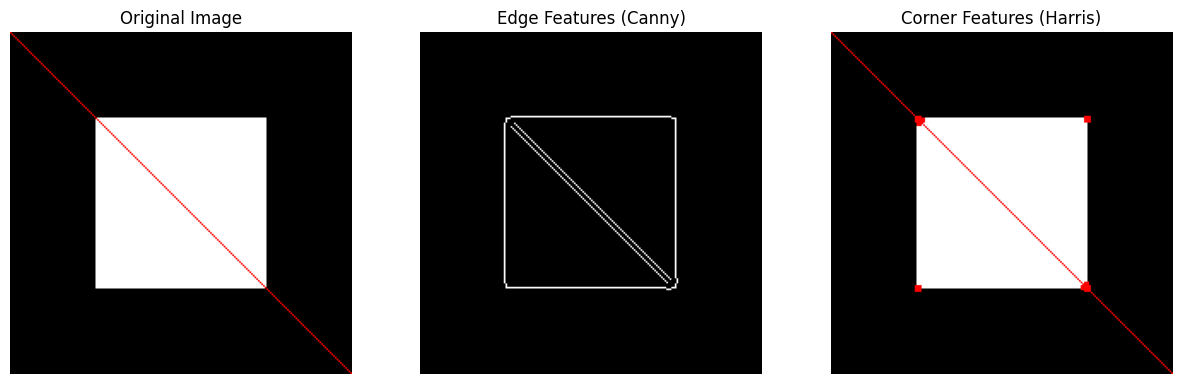

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

# 1. Load and Preprocess Image
image = cv2.imread('image.jpg')

# Check if the image was loaded successfully
if image is None:
    print("Warning: 'image.jpg' not found. Creating a dummy image for demonstration.")
    # Create a dummy grayscale image (e.g., 200x200 black image)
    dummy_size = 200
    image = np.zeros((dummy_size, dummy_size, 3), dtype=np.uint8)
    # Add a white square in the middle for some features
    image[dummy_size//4:3*dummy_size//4, dummy_size//4:3*dummy_size//4] = [255, 255, 255]
    # Add a diagonal line for edge detection
    for i in range(dummy_size):
        image[i, i] = [0, 0, 255] # Blue diagonal

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 2. Feature Extraction: Edges (Canny Edge Detector)
edges = cv2.Canny(blurred, 50, 150)

# 3. Feature Extraction: Corners (Harris Corner Detector)
gray_float = np.float32(gray)
dst = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)
dst_norm = cv2.dilate(dst, None)
corner_image = image.copy()
corner_image[dst_norm > 0.01 * dst_norm.max()] = [0, 0, 255] # Mark corners in Red

# 4. Feature Representation: Texture (Gray-Level Co-occurrence Matrix - GLCM)
# Calculate GLCM: distance=1, angles=[0, pi/4, pi/2, 3pi/4]
glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                    levels=256, symmetric=True, normed=True)

# Extract Texture Features (Contrast and Energy)
contrast = graycoprops(glcm, 'contrast').mean()
energy = graycoprops(glcm, 'energy').mean()
print(f"GLCM Features - Contrast: {contrast:.2f}, Energy: {energy:.2f}")

# 5. Visualization using Matplotlib
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image'), plt.axis('off')

plt.subplot(1, 3, 2), plt.imshow(edges, cmap='gray')
plt.title('Edge Features (Canny)'), plt.axis('off')

plt.subplot(1, 3, 3), plt.imshow(cv2.cvtColor(corner_image, cv2.COLOR_BGR2RGB))
plt.title('Corner Features (Harris)'), plt.axis('off')

plt.show()